# 03 - Bundle demand proxy
No direct user-bundle purchase file exists in this Kaggle archive. The source paper reports a separate user-bundle interaction graph, but this project cannot recover those labels from the files it received. Instead, it constructs an upper-bound ownership-compatibility proxy. This is not a purchase reconstruction or a reproduction of the paper's 87,565 bundle interactions.

For each bundle, we compute:
- users_own_all: number of users who own every item in the bundle
- users_own_any: number of users who own at least one item
- avg_playtime_overlap: average total playtime of bundle games among users who own any

Caveat: owning all items does not prove the user bought the bundle. They may have bought the games separately. These are demand/interest proxies.

We use an inverted index (item -> bundles) to keep the computation efficient: O(ownership records) instead of O(users * bundles).

# Upper-Bound Compatibility Count
If user_A has games {A, B, C, D, E}, and bundle_A has games {A, B, C} and bundle_B has games {C, D, E}, then user_A gets classified into having bought both bundles A and B.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

## Cleaned tables from notebooks 01 and 02


In [6]:
bundle_df = pd.read_csv('../outputs/tables/bundle_df.csv', dtype={'bundle_id': str})
bundle_items_df = pd.read_csv('../outputs/tables/bundle_items_df.csv',
                               dtype={'bundle_id': str, 'item_id': str})
user_items_df = pd.read_csv('../outputs/tables/user_items_df.csv',
                            dtype={'user_id': str, 'item_id': str})

print('bundle_df:', bundle_df.shape)
print('bundle_items_df:', bundle_items_df.shape)
print('user_items_df:', user_items_df.shape)


bundle_df: (615, 11)
bundle_items_df: (3525, 6)
user_items_df: (5094082, 5)


## Building data structures for efficient lookup
(wow! CS2040 application)

In [7]:
bundle_item_sets = (bundle_items_df
                    .groupby('bundle_id')['item_id']
                    .apply(frozenset)
                    .to_dict())
print(f'{len(bundle_item_sets)} bundles with item sets')
# now: {bundle_1: frozenset({'A', 'B'}), bundle_2: frozenset({'B', 'C'})}
#frozensets are immutable and hashable, so they can be used as dictionary keys or set elements. frozenset:set == tuple:list?

# Inverted Index; faster than checking all 615 bundles
item_to_bundles = defaultdict(list)
for bid, items in bundle_item_sets.items():
    for iid in items:
        item_to_bundles[iid].append(bid)
print(f'inverted index covers {len(item_to_bundles)} unique items')
# now:  {''A': [bundle_1], 'B': [bundle_1, bundle_2], 'C': [bundle_2]}

owned_item_ids = set(user_items_df['item_id'].unique())
bundle_items_in_panel = {}
bundle_coverage = {}

# how many items in this bundle are owned by at least one user?
for bid, items in bundle_item_sets.items():
    in_panel = sum(1 for iid in items if iid in owned_item_ids) 
    bundle_items_in_panel[bid] = in_panel
    bundle_coverage[bid] = in_panel / len(items) # [0, 1]

print('\n')
cov_series = pd.Series(bundle_coverage)
print(f'bundle items in panel: {len(owned_item_ids & set(item_to_bundles))} / {len(item_to_bundles)}')
print(f'bundles with full coverage: {(cov_series == 1).sum()}')
print(f'bundles with zero coverage: {(cov_series == 0).sum()}')
print(f'bundles with partial coverage: {((cov_series > 0) & (cov_series < 1)).sum()}')

615 bundles with item sets
inverted index covers 2798 unique items


bundle items in panel: 1394 / 2798
bundles with full coverage: 238
bundles with zero coverage: 70
bundles with partial coverage: 307


## Panel Coverage Caveat
The ownership panel (australian_users_items) does not cover every game that
appears in a bundle. Only about half of bundle items are owned by anyone in
the panel. So `users_own_all` is only a meaningful demand signal for bundles
where all items are covered. We keep `panel_coverage` as a column and filter
to full-coverage bundles when we need a clean `users_own_all`.

In [8]:
#The goal here: for every user and every bundle, how many games from this bundle does this user own?

# for each bundle: count users who own all items, any items, and summed playtime
bundle_owns_all   = defaultdict(int)   # user owned every item
bundle_owns_any   = defaultdict(int)   # user owned at least one item
bundle_playtime   = defaultdict(float) # total playtime across all users who own any item
bundle_size       = {bid: len(items) for bid, items in bundle_item_sets.items()}

user_bundle_overlap = defaultdict(int) # number of user-owned items in that comes in bundles
user_bundle_playtime = defaultdict(float) # duration played by user of item that comes in bundles

print('takes a while to load this...')
for row in user_items_df.itertuples(index=False):
    bundles_for_item = item_to_bundles.get(row.item_id, []) # User has game_A, which bundles has game_A?
    for bid in bundles_for_item:
        key = (row.user_id, bid)
        user_bundle_overlap[key] += 1
        user_bundle_playtime[key] += row.playtime_forever

print(f'{len(user_bundle_overlap):,} (user, bundle) pairs with at least 1 item in common')


takes a while to load this...
877,114 (user, bundle) pairs with at least 1 item in common


In [9]:
for (user_id, bid), k in user_bundle_overlap.items(): # k is the number of bundles the user owns
    bundle_owns_any[bid] += 1 # Count user if they own at least 1 game from bundle
    bundle_playtime[bid] += user_bundle_playtime[(user_id, bid)]
    if k == bundle_size.get(bid, -1): # if user owns all games in the bundle
        bundle_owns_all[bid] += 1

proxy_rows = []
for bid in bundle_item_sets:
    owns_any = bundle_owns_any[bid]
    proxy_rows.append({
        'bundle_id':           bid,
        'n_bundle_items':      bundle_size[bid],
        'items_in_panel':      bundle_items_in_panel[bid],
        'panel_coverage':      bundle_coverage[bid],
        'users_own_all':       bundle_owns_all[bid],
        'users_own_any':       owns_any,
        'avg_playtime_overlap': bundle_playtime[bid] / owns_any if owns_any > 0 else np.nan
    })

proxy_df = pd.DataFrame(proxy_rows)
print(proxy_df.describe().round())

       n_bundle_items  items_in_panel  panel_coverage  users_own_all  \
count           615.0           615.0           615.0          615.0   
mean              6.0             3.0             1.0           75.0   
std               8.0             4.0             0.0          729.0   
min               1.0             0.0             0.0            0.0   
25%               2.0             1.0             0.0            0.0   
50%               3.0             2.0             0.0            0.0   
75%               5.0             3.0             1.0            3.0   
max              89.0            45.0             1.0        13837.0   

       users_own_any  avg_playtime_overlap  
count          615.0                 545.0  
mean          1426.0                 568.0  
std           4746.0                1488.0  
min              0.0                   0.0  
25%              9.0                 116.0  
50%             85.0                 204.0  
75%            651.0                

In [11]:
# proxy_df does not have readable metadata such asbundle_name, final_price, implied_discount_rate
proxy_full = proxy_df.merge(
    bundle_df[['bundle_id', 'bundle_name', 'n_items', 'final_price', 'implied_discount_rate']],
    on='bundle_id', how='left'
)

full_cov = proxy_full[proxy_full['panel_coverage'] == 1.0] 
# Only keeps bundles where all items are in panel. Hence, full_cov is the clean data subset
print(f'Ranking among {len(full_cov)} full-coverage bundles by users_own_all:')
print(full_cov[['bundle_name', 'n_items', 'users_own_all', 'users_own_any', 'implied_discount_rate']]
      .sort_values('users_own_all', ascending=False).head(9).to_string(index=False))

Ranking among 238 full-coverage bundles by users_own_all:
            bundle_name  n_items  users_own_all  users_own_any  implied_discount_rate
          Portal Bundle        2          13837          28940               0.250167
   BioShock Triple Pack        3           6951          14671               0.000000
     Left 4 Dead Bundle        2           5890          37299               0.250125
  Half-Life 1 Anthology        4           5832           8223               0.450721
Source Multiplayer Pack        3           4028          29042               0.150129
    The Witcher Trilogy        3           1542          12493               0.100043
             More Spore        3           1454           3773               0.330165
    Resident Evil 4/5/6        3            394           2993               0.140060
              Trinelogy        3            385           7404               0.300158


## Plots

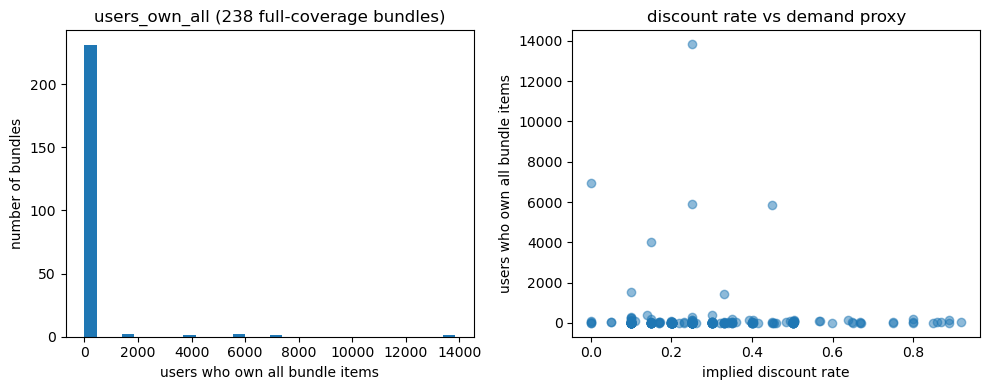

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# left: distribution of users_own_all for full-coverage bundles only
ax = axes[0]
ax.hist(full_cov['users_own_all'], bins=30)
ax.set_xlabel('users who own all bundle items')
ax.set_ylabel('number of bundles')
ax.set_title(f'users_own_all ({len(full_cov)} full-coverage bundles)')

# right: discount rate vs demand proxy, full-coverage bundles only
ax = axes[1]
valid = full_cov.dropna(subset=['implied_discount_rate', 'users_own_all'])
ax.scatter(valid['implied_discount_rate'], valid['users_own_all'], alpha=0.5)
ax.set_xlabel('implied discount rate')
ax.set_ylabel('users who own all bundle items')
ax.set_title('discount rate vs demand proxy')

plt.tight_layout()
plt.savefig('../outputs/figures/03_demand_proxy.png')
plt.show()

In [14]:
proxy_full.to_csv('../outputs/tables/bundle_demand_proxy.csv', index=False)


## What comes next

`users_own_all` (restricted to full-coverage bundles) is our primary demand proxy. `users_own_any` is a softer reach measure that tolerates partial coverage.

Notebook 04 sharpens this proxy with a minimum-cost attribution that resolves overlapping bundles. Notebook 05 then asks whether the bundle discount rate and bundle size explain descriptive variation in the proxy. That regression cannot identify a demand curve or price a bundle. The live project therefore moves from these diagnostics to leakage-controlled latent preference estimation and, separately, scenario-conditional bundle design.

Note the direction of the likely bias: bundle price and discount are not randomly assigned. Publishers set bigger discounts on bundles they expect to sell less, so a naive regression of demand on discount can show the wrong sign. We treat the first regression as descriptive, not causal.